# Applying Spectral Derivative Pigment (SDP) Phytoplankton Community Composition Algorithm to OCI data

**Author(s):** Anna Windle (NASA, SSAI), Max Danenhower (Bowdoin College), Sasha Kramer (Boston University)

Last updated: July 2, 2026

<div class="alert alert-success" role="alert">

The following notebooks are **prerequisites** for this tutorial.

- Learn with OCI: [Data Access][oci-data-access]

</div>

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data.

</div>

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: /notebooks/oci_data_access/

## Summary

This notebook applies the inversion algorithm described in [Kramer et al., 2022][Kramer-et-al] to estimate phytoplankton pigment concentrations from PACE OCI Rrs data. This algorithm, called Spectral Derivative Pigment (SDP), is currently being implemented in OBPG's OCSSW software. This work was originally [developed in MatLab](https://github.com/sashajane19/Rrs_pigments) by Sasha Kramer and subsequently [translated to Python](https://github.com/max-danenhower/rrs-SDP-pigments/) by Max Danenhower. This tutorial demonstrates how to apply the Python SDP algorithm to Level-2 (L2) PACE OCI data.

[Kramer-et-al]: https://doi.org/10.1016/j.rse.2021.112879

## Learning Objectives

At the end of this notebook you will know:

- How to use a packaged Python project
- How to run the SDP algorithm on PACE OCI L2 data

## 1. Setup

The SDP Python code has been packaged to allow it to be easily installed, imported, and reused.
While the package is not on PyPI or conda-forge, it can be installed directly from the [source repository][sdp] on GitHub.
If you have followed the setup instructions, then SDP is available to import along with the other packages needed for this notebook.

[sdp]: https://github.com/max-danenhower/rrs-SDP-pigments/

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

crs = ccrs.PlateCarree()

In [2]:
pip install ray openpyxl #scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("src").resolve()))
import sdp
from sdp.core import sdp_from_pace

/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:143: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  L2_path : strclimatology\sst_climatology.nc
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:283: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  def sdp_from_pace(pace_file, output_str, sss_file='climatology\sss_climatology_woa2009.nc', sst_file='climatology\sst_climatology.nc'):
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:283: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  def sdp_from_pace(pace_file, output_str, sss_file='climatology\sss_climatology_woa2009.nc', sst_file='climatology\sst_climatology.nc'):


Set (and persist to your home directory on the host, if needed) your Earthdata Login credentials.

In [4]:
auth = earthaccess.login()

# 2. Access and open data

We need the following data to run SDP:
* Rrs: PACE OCI Level-2 AOP data products
* Sea surface salinity: JPL SMAP-SSS V5.0 CAP, 8-day running mean, level 3 mapped, sea surface salinity (SSS) product from the NASA Soil Moisture Active Passive (SMAP) observatory
* Sea surface temperature: Group for High Resolution Sea Surface Temperature (GHRSST) Level 4 sea surface temperature

We can use `earthaccess` to find PACE OCI l2 data. We will use a specific granule using the `granule_name` argument:

In [5]:
results = earthaccess.search_data(
    short_name=["PACE_OCI_L2_AOP"],
    temporal= ("2026-03-03", "2026-03-03"),
    granule_name='*20260303T183722*')
results

[Collection: {'Version': '3.2', 'ShortName': 'PACE_OCI_L2_AOP'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 1.3079, 'Longitude': -73.34805}, {'Latitude': 19.17547, 'Longitude': -76.59283}, {'Latitude': 14.0328, 'Longitude': -101.25039}, {'Latitude': -3.72917, 'Longitude': -97.05367}, {'Latitude': 1.3079, 'Longitude': -73.34805}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-03-03T18:37:22Z', 'EndingDateTime': '2026-03-03T18:42:21Z'}}
 Size(MB): 437.3645133972168
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260303T183722.L2.OC_AOP.V3_2.nc']]

In [6]:
paths = earthaccess.open(results)
paths

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260303T183722.L2.OC_AOP.V3_2.nc>]

Let's take a quick look at Rrs at 500nm:

In [21]:
datatree = xr.open_datatree(paths[0])
rrs = datatree["geophysical_data"]["Rrs"]
for item in ("longitude", "latitude"):
    rrs[item] = datatree["navigation_data"][item]
rrs

<xarray.DataArray 'Rrs' (number_of_lines: 1710, pixels_per_line: 1272,
                         wavelength: 172)> Size: 1GB
[374120640 values with dtype=float32]
Coordinates:
    longitude   (number_of_lines, pixels_per_line) float32 9MB ...
    latitude    (number_of_lines, pixels_per_line) float32 9MB ...
  * wavelength  (wavelength) float32 688B 346.0 348.5 350.9 ... 716.8 719.3
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

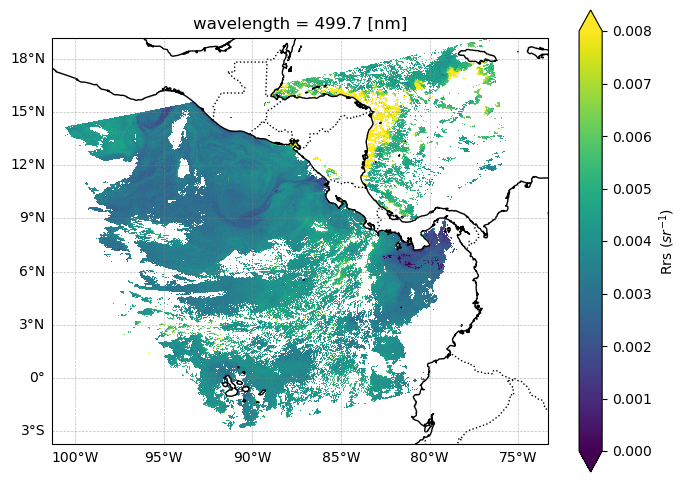

In [24]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": crs})

data = rrs.sel({"wavelength": 500}, method="nearest")
data.plot(
    x="longitude",
    y="latitude",
    vmin=0,
    vmax=0.008,
    ax=ax,
    cbar_kwargs={"label": "Rrs ($sr^{-1}$)"},
)

#ax.set_extent([-135, -115, 35, 55], crs=crs)
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(
    draw_labels=["left", "bottom"],
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
plt.show()

We can use the `load_data()` function to download sss and sst:

TODO: could move this to core.py?

In [11]:
def load_data(tspan):
    '''
    Downloads one L2 PACE apparent optical properties (AOP) file that intersects the coordinate box passed in, as well as 
    temperature and salinity files. Data files are saved to local folders named 'L2_rrs_data', 'sal_data', and 'temp_data'.

    Parameters:
    -----------
    tspan : tuple of str
        A tuple containing two strings both with format 'YYYY-MM-DD'. The first date in the tuple must predate the second date in the tuple.
    bbox : tuple of floats or ints
        A tuple representing spatial bounds in the form (lower_left_lon, lower_left_lat, upper_right_lon, upper_right_lat).

    Returns:
    --------
    list
        A list of file paths to a PACE L2 AOP files intersecting the passed in bounding box.
    string
        A single file path to a salinity file.
    string
        A single file path to a temperature file.
    '''

    #L2_results = earthaccess.search_data(
    #    short_name='PACE_OCI_L2_AOP',
    #    bounding_box=bbox,
    #    temporal=tspan
    #)
    #if (len(L2_results) > 0):
    #    L2_paths = earthaccess.download(L2_results, 'L2_rrs_data')
    #else:
    #    L2_paths = []
     #   print('No L2 AOP data found')

    sal_results = earthaccess.search_data(
        short_name='SMAP_JPL_L3_SSS_CAP_8DAY-RUNNINGMEAN_V5',
        temporal=tspan,
        count=1
    )
    if (len(sal_results) > 0):
        sal_paths = earthaccess.download(sal_results, 'sal_data')
    else:
        sal_paths = []
        print('No salinity data found')

    temp_results = earthaccess.search_data(
        short_name='MUR-JPL-L4-GLOB-v4.1',
        temporal=tspan,
        count=1
    )
    if (len(temp_results) > 0):
        temp_paths = earthaccess.download(temp_results, 'temp_data')
    else:
        temp_paths = []
        print('No temperature data found')

    return sal_paths[0], temp_paths[0]

load_data(tspan = ("2026-03-03", "2026-03-03"))

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

(PosixPath('sal_data/SMAP_L3_SSS_20260227_8DAYS_V5.0.nc'),
 PosixPath('temp_data/20260303090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc'))

## 2. Run SDP on L2 Data

Now we're ready to run SDP. Let's name what we want the outfile to be:

In [11]:
output_file = paths[0].full_name.split("/")[-1]
output_file = output_file.replace(".nc", "_SDP_pigments.nc")
output_file

'PACE_OCI.20260303T183722.L2.OC_AOP.V3_2_SDP_pigments.nc'

And then run it! Note that it will run up memory and blow up in the cloud......

In [12]:
%%time

sdp_from_pace(paths[0], output_file, 
             sss_file='/glusteruser/awindled/rrs-SDP-pigments/sal_data/SMAP_L3_SSS_20260227_8DAYS_V5.0.nc',
             sst_file='/glusteruser/awindled/rrs-SDP-pigments/temp_data/20260303090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc')

generating pigments from PACE
starting interpolation
north 19.175472 south -3.7291715 east -73.34805 west -101.25039


/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:229: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(temp_path) as ds:
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:231: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray

interpolation complete: 62.422873608302325
rrs_interp shape: (2175120, 374)
(1060248,) (1060248,) (1060248, 301)
0
calculating residuals


/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:327: RuntimeWarning: overflow encountered in exp
  bbp_s = 2.0 * (1 - 1.2 * np.exp(-0.9 * Rrs_440 / Rrs_555))
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:328: RuntimeWarning: overflow encountered in power
  bbp = (443 / wavelengths.reshape(-1, 1)) ** bbp_s
2026-07-02 15:21:02,794	INFO worker.py:2024 -- Started a local Ray instance.


ray availble resources {'memory': 99967669044.0, 'CPU': 48.0, 'node:192.168.2.31': 1.0, 'object_store_memory': 42843286732.0, 'node:__internal_head__': 1.0} 



(run_batch pid=2910874) /glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:201: RuntimeWarning: invalid value encountered in power
(run_batch pid=2910874)   aph = A * IOPs[0]**B
(run_batch pid=2912219) /glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:201: RuntimeWarning: invalid value encountered in power [repeated 16x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(run_batch pid=2912219)   aph = A * IOPs[0]**B [repeated 16x across cluster]
(run_batch pid=2911837) /glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:204: RuntimeWarning: invalid value encountered in divide
(run_batch pid=2911837)   x = bb / (a + bb)
(run_batch pid=2912022) /glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:201: RuntimeWarning: invalid value encountered in power [rep

residuals calculated 601.9516232339665
calculating 2nd derivative
2nd derivative calculated 1.1759856538847089
(1060248, 299)
running coefs
coefs run complete 29.33223914867267
sdp calculation complete
CPU times: user 5min 7s, sys: 35.7 s, total: 5min 43s
Wall time: 11min 47s


In [25]:
TODO: should we get rid of warnings? should we use ray?

Object `ray` not found.


# 3. Open and plot SDP output

In [26]:
dat = xr.open_dataset('PACE_OCI.20260303T183722.L2.OC_AOP.V3_2_SDP_pigments.nc')
dat

<xarray.Dataset> Size: 244MB
Dimensions:          (number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * number_of_lines  (number_of_lines) int64 14kB 0 1 2 3 ... 1707 1708 1709
  * pixels_per_line  (pixels_per_line) int64 10kB 0 1 2 3 ... 1269 1270 1271
    longitude        (number_of_lines, pixels_per_line) float32 9MB ...
    latitude         (number_of_lines, pixels_per_line) float32 9MB ...
Data variables: (12/13)
    chla             (number_of_lines, pixels_per_line) float64 17MB ...
    chlb             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc             (number_of_lines, pixels_per_line) float64 17MB ...
    zea              (number_of_lines, pixels_per_line) float64 17MB ...
    dvchla           (number_of_lines, pixels_per_line) float64 17MB ...
    butfuco          (number_of_lines, pixels_per_line) float64 17MB ...
    ...               ...
    allo             (number_of_lines, pixels_per_line) float64 17MB ...
    neo              (number_of_lines, pixels_per_line) float64 17MB ...
    viola            (number_of_lines, pixels_per_line) float64 17MB ...
    fuco             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc3            (number_of_lines, pixels_per_line) float64 17MB ...
    perid            (number_of_lines, pixels_per_line) float64 17MB ...

You can see all the different pigment concentrations derived for our L2 granule. Let's plot them:

/tmp/ipykernel_2905887/2784757569.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


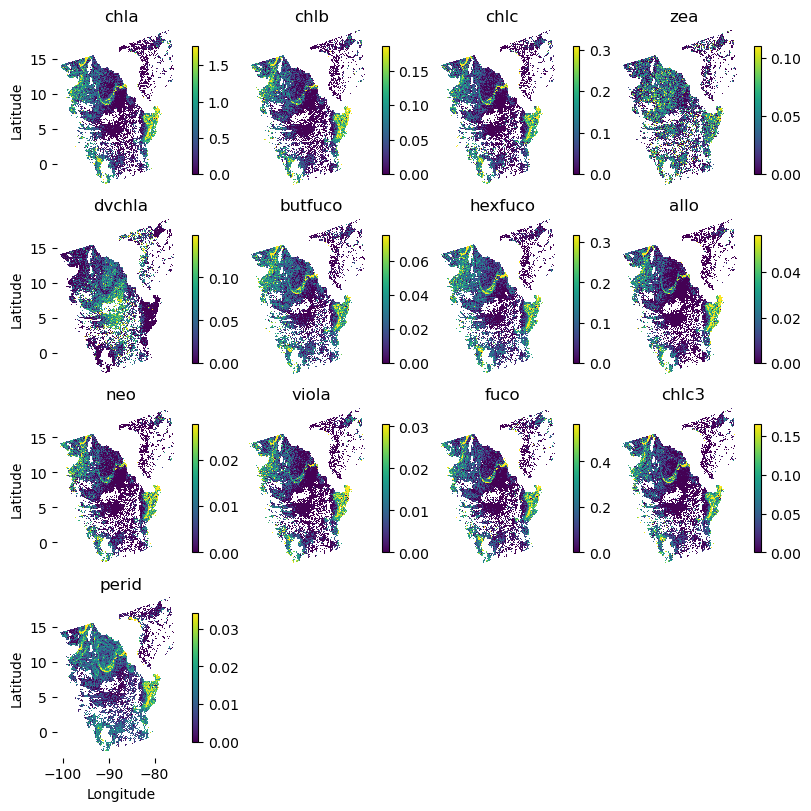

In [31]:
vars_to_plot = list(dat.data_vars)

ncols = 4
nrows = int(np.ceil(len(vars_to_plot) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(8, 8),
    constrained_layout=True
)

axes = axes.ravel()

for i, (ax, var) in enumerate(zip(axes, vars_to_plot)):

    im = ax.pcolormesh(
        dat.longitude,
        dat.latitude,
        dat[var],
        shading="auto",
        vmin=np.nanpercentile(dat[var], 2),
        vmax=np.nanpercentile(dat[var], 98),
    )

    ax.set_title(var)

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    row = i // ncols
    col = i % ncols

    # Show latitude labels only on the first column
    if col == 0:
        ax.tick_params(axis="y", left=True, labelleft=True)
        ax.set_ylabel("Latitude")
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)

    # Show longitude labels only on the last row
    if row == nrows - 1:
        ax.tick_params(axis="x", bottom=True, labelbottom=True)
        ax.set_xlabel("Longitude")
    else:
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    plt.colorbar(im, ax=ax, shrink=0.8)

# Remove unused axes
for ax in axes[len(vars_to_plot):]:
    ax.remove()

plt.show()